In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from transformers import ViTFeatureExtractor, ViTModel
from torchvision import models
import numpy as np

# Choose device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load EfficientNet and ViT models
efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT).features.to(device)
vit_model = ViTModel.from_pretrained("google/vit-base-patch16-224").to(device)
vit_feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224")

# Define an ensemble model.
class EnsembleModel(nn.Module):
    def __init__(self, num_classes):
        super(EnsembleModel, self).__init__()
        self.efficientnet = efficientnet
        self.vit = vit_model
        # Global pooling to reduce the spatial size of EfficientNet's output.
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        # The fully connected layer takes features from both branches.
        self.fc = nn.Linear(1280 + 768, num_classes)

    def forward(self, x):
        # EfficientNet branch.
        eff_features = self.efficientnet(x)
        eff_features = self.pool(eff_features)
        eff_features = torch.flatten(eff_features, start_dim=1)

        # ViT branch: convert each tensor in the batch to a PIL image.
        pil_images = []
        for img_tensor in x:
            img = transforms.ToPILImage()(img_tensor.cpu())
            pil_images.append(img)
        vit_inputs = vit_feature_extractor(images=pil_images, return_tensors="pt")
        vit_inputs = {k: v.to(device) for k, v in vit_inputs.items()}
        vit_outputs = self.vit(**vit_inputs).last_hidden_state[:, 0, :]

        # Combine features and pass through the final layer.
        features = torch.cat((eff_features, vit_outputs), dim=1)
        output = self.fc(features)
        return output

num_classes = 4
model = EnsembleModel(num_classes)
model.load_state_dict(torch.load("./assets/models/ensemble_model.pth"))
model.to(device)
model.eval()

print("Model loaded successfully and is ready for evaluation.")

/home/kiwi/projects/assignments/six_phases/parkinsons-mri/.pixi/envs/default/lib/python3.10/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
2025-03-07 01:10:00.588663: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-07 01:10:00.630284: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/kiw

Model loaded successfully and is ready for evaluation.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
# Load trained model
#model_path = "assets/models/ensemble_model.pth"
#model = torch.load(model_path)
#model.eval()

In [5]:
def evaluate_model(model, dataloader, device):
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # Compute metrics
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(4), yticklabels=range(4))
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       502
           1       0.50      0.87      0.64       543
           2       0.70      0.84      0.76       480

    accuracy                           0.58      1525
   macro avg       0.40      0.57      0.47      1525
weighted avg       0.40      0.58      0.47      1525



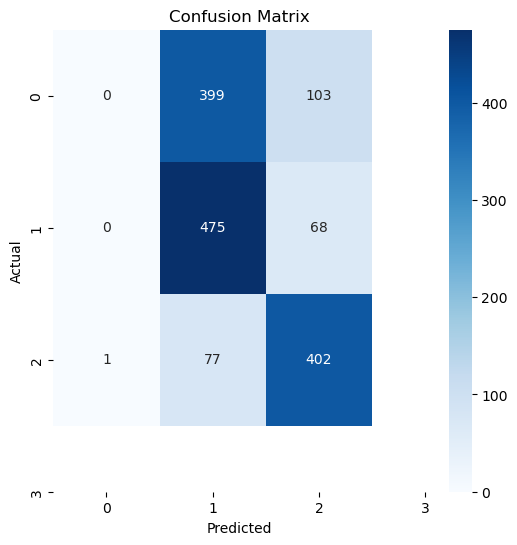

In [8]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

# Load the preprocessed data
data = np.load("./assets/preprocessed_data/dataset.npz", allow_pickle=True)
X_val = data["X_val"]
y_val = data["y_val"]

# Convert images to torch tensors.
# The images are in (N, height, width, channels) format.
# We change them to (N, channels, height, width) as required by PyTorch.
X_val_tensor = torch.tensor(X_val).permute(0, 3, 1, 2).float()

# The labels are one-hot encoded. We convert them to class indices.
y_val_tensor = torch.tensor(y_val).argmax(dim=1)

# Create the dataset and DataLoader for the validation set.
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Now, call the evaluation function.
evaluate_model(model, val_loader, device)

In [18]:
def grad_cam(model, image, target_class, device):
    image = image.unsqueeze(0).to(device)
    model.zero_grad()

    # Dictionary to hold the feature maps.
    feat_dict = {}

    # Hook function to capture the output of the efficientnet branch.
    def hook_fn(module, inp, output):
        feat_dict["feat"] = output
        output.retain_grad()  # Ensure we keep the gradients.
    
    # Register the hook.
    hook_handle = model.efficientnet.register_forward_hook(hook_fn)

    # Forward pass.
    output = model(image)
    
    # Remove the hook after the forward pass.
    hook_handle.remove()

    # Compute the loss based on the target class.
    loss = output[0, target_class]
    loss.backward()

    # Get the feature maps and gradients.
    feat = feat_dict.get("feat", None)
    if feat is None:
        print("Feature maps not captured.")
        return

    grad = feat.grad
    if grad is None:
        print("No gradients computed for the feature maps.")
        return

    # Compute the weights and the activation map.
    weights = torch.mean(grad, dim=(1, 2), keepdim=True)
    cam = torch.sum(weights * feat[0], dim=0)
    cam = torch.clamp(cam, min=0).cpu().detach().numpy()

    # Normalize the heatmap.
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    # Plot the image and overlay the heatmap.
    plt.imshow(image.squeeze().permute(1, 2, 0).cpu().numpy())
    plt.imshow(cam, cmap="jet", alpha=0.5)
    plt.title("Grad-CAM Visualization")
    plt.axis("off")
    plt.show()


TypeError: Invalid shape (1280, 7, 7) for image data

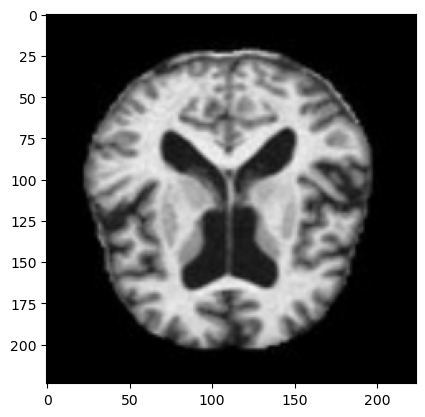

In [19]:
# Example Grad-CAM usage
data_iter = iter(val_loader)
sample_image, sample_label = next(data_iter)
grad_cam(model, sample_image[0], sample_label[0].item(), device)

In [20]:
# Save model
torch.save(model, "parkinsons_mri_model.pth")
print("Model saved successfully.")

Model saved successfully.
